In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import re

sc.set_figure_params(dpi=80)
%config InlineBackend.figure_format='retina'

import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))

from general_utils import ismember, grep

In [ ]:
# Set file paths
signature_path = "../signatures"
file_code = "KPLOH"
input_file = "../data/Reyes_KPLOH_SUBSET_pretumor_PDAC__integrated.h5ad"
annotations_file = "../data/Reyes_KPLOH_SUBSET_pretumor_PDAC__annotated.csv"
os.makedirs(output_path, exist_ok=True)

Import raw data and transfer annotations, making sure that the adata and dataframe are align by cell ids

In [ ]:
adata = sc.read_h5ad(input_file)
annotations = pd.read_csv(annotations_file, index_col = 0)

adata.obs_names = [re.sub('-\d+-\d+$', '', x) for x in adata.obs_names]
annotations = annotations.loc[adata.obs_names,:].copy()

display(np.mean([x==y for x,y in zip(adata.obs_names, annotations.index)]))

for my_obs in annotations.columns:
    adata.obs[my_obs] = annotations[my_obs]

1.0

Focus only on primary tumor vs p53 proficient premalignant cells

In [ ]:
adata_sub = adata[adata.obs['condition_simple'] != 'K4pretumorSP',:].copy()
removed = adata.n_obs - adata_sub.n_obs
print("Removed %d cells from pre-tumor SP samples" % (removed))
adata_sub = adata_sub[adata_sub.obs['cell_type_simple'] != 'TumorPremalignant',:].copy()
removed = adata.n_obs - adata_sub.n_obs
print("Removed %d cells from pre-tumor SP samples and tumor pre-malignant annotations" % (removed))
adata_sub = adata_sub[adata_sub.obs['batch'] <= 2,:].copy()
removed = adata.n_obs - adata_sub.n_obs
print("Removed %d cells from pre-tumor SP samples and tumor pre-malignant annotations, and batches 7 or 8" % (removed))
adata_sub = adata_sub[adata_sub.obs['condition'] != 'K6ctrl',:].copy()
removed = adata.n_obs - adata_sub.n_obs
print("Removed %d cells from pre-tumor SP samples and tumor pre-malignant annotations, and batches 7 or 8, and metastasis samples" % (removed))


Removed 1472 cells from pre-tumor SP samples
Removed 1487 cells from pre-tumor SP samples and tumor pre-malignant annotations
Removed 9862 cells from pre-tumor SP samples and tumor pre-malignant annotations, and batches 7 or 8
Removed 13364 cells from pre-tumor SP samples and tumor pre-malignant annotations, and batches 7 or 8, and metastasis samples


### Pseudobulking

Prepare output path

In [ ]:
groupby = ['tumor_cells', 'prefix']
group_str = '_'.join(groupby)
output_path = os.path.join(signature_path, file_code, group_str)
os.makedirs(output_path, exist_ok=True)

Aggregate unnormalized cellbender counts

In [ ]:
df = pd.DataFrame(np.array(adata_sub.layers['cellbender'].todense()))
df.columns = adata_sub.var_names
for i in groupby:
    df[i] = adata_sub.obs[i].to_numpy()

df_agg = df.groupby(groupby).agg('sum')
df_agg.index = df_agg.index.to_flat_index()

current_index = ['_'.join([str(x0) + '_' + str(y0) for x0,y0 in zip(groupby,y)]) for y in df_agg.index]
df_agg.index = current_index

pseudobulk_counts = df_agg.T

pseudobulk_counts.to_csv(os.path.join(output_path, 'cellbender_counts_pseudobulk.csv'))

### Differential gene expression with DESEQ2 and rpy2

In [ ]:
import rpy2
from rpy2.robjects import pandas2ri
import rpy2.robjects as robjects

pandas2ri.activate()
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
def read_R_data_frame(r_command):
    my_data_frame = robjects.r(r_command)
    df = pd.DataFrame.from_dict({ key : np.asarray(my_data_frame.rx2(key)) for key in my_data_frame.names })
    return(df)

In [ ]:
metadata_extractor = '_'.join([x + '_(.*)' for x in groupby])
metadata = pd.DataFrame([re.findall(metadata_extractor, x)[0] for x in pseudobulk_counts.columns])
metadata.columns = groupby
metadata.index = pseudobulk_counts.columns
np.unique(metadata[groupby[0]])

array(['False', 'True'], dtype=object)

In [ ]:
cell_type_column = groupby[0]
cell_types = ['False', 'True']

valid_columns = ismember(metadata[cell_type_column], cell_types)[1]
pseudobulk_counts_sub = pseudobulk_counts.loc[:,valid_columns].copy()
metadata = metadata.loc[valid_columns,:].copy()

filtering_str = 'TUMORCELLS_' + '_'.join(cell_types)


In [ ]:
df_r = pandas2ri.py2rpy_pandasdataframe(pseudobulk_counts_sub)
metadata_r = pandas2ri.py2rpy_pandasdataframe(metadata)

query = cell_types[1]
reference = cell_types[0]

In [ ]:
%%R -i df_r,metadata_r,cell_type_column,query,reference
library(DESeq2)

get_UP <- function(res, pval_thresh, fc_thresh){
	res <- res[!is.na(res$padj),]
	res <- res[res$padj < pval_thresh & res$log2FoldChange > fc_thresh,]
	return(res)
}
get_DOWN <- function(res, pval_thresh, fc_thresh){
	res <- res[!is.na(res$padj),]
	res <- res[res$padj < pval_thresh & res$log2FoldChange < fc_thresh,]
	return(res)
}

print(cell_type_column)
print(query)
print(reference)

dds <- DESeqDataSetFromMatrix(countData = df_r, colData = metadata_r, design= as.formula(sprintf("~ %s", cell_type_column)))
keep <- rowSums(counts(dds) >= 10) >= 2
dds <- dds[keep,]
dds <- DESeq(dds)
res <- data.frame(results(dds, contrast = c(cell_type_column, query, reference)))

UP <- data.frame(get_UP(res, 0.001, 0.5))
DOWN <- data.frame(get_DOWN(res, 0.001, -0.5))

R[write to console]: Loading required package: S4Vectors

R[write to console]: Loading required package: stats4

R[write to console]: Loading required package: BiocGenerics

R[write to console]: 
Attaching package: ‘BiocGenerics’


R[write to console]: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


R[write to console]: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


R[write to console]: 
Attaching package: ‘S4Vectors’


R[write to console]: The following object is masked from ‘package:utils’:

    findMatches


R[write to console]: The following 

[1] "tumor_cells"
[1] "True"
[1] "False"


R[write to console]: converting counts to integer mode

R[write to console]: estimating size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing



In [ ]:
UP = robjects.r('UP')
DOWN = robjects.r('DOWN')
res = robjects.r('res')

res.to_csv(os.path.join(output_path, 'DESEQ220250426_FILTER_%s_CONTRAST_%s_vs_%s.csv' % (filtering_str, query, reference)))
os.path.join(output_path, 'DESEQ220250426_FILTER_%s_CONTRAST_%s_vs_%s.csv' % (filtering_str, query, reference))

'../signatures/KPLOH/tumor_cells_prefix/DESEQ220250426_FILTER_TUMORCELLS_False_True_CONTRAST_True_vs_False.csv'

Visualize differential gene expression results

Text(0.5, 0, 'log2 fold-change')

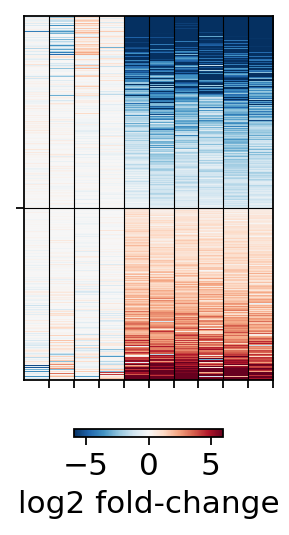

In [ ]:
## Filter differential gene expression result

res_filtered = res.loc[np.union1d(UP.index, DOWN.index),:].copy()
res_filtered = res_filtered.iloc[np.argsort(res_filtered['log2FoldChange']),:].copy()

# Normalize and compute log2fc
data_linear = np.ravel(pseudobulk_counts_sub)
pseudocount = np.min(data_linear[data_linear > 0]) * 0.1
df_filtered = pseudobulk_counts_sub.loc[res_filtered.index,:].copy()
df_filtered = df_filtered + pseudocount
normBy = pseudobulk_counts_sub.mean(axis=0)
df_filtered = df_filtered.divide(normBy, axis=1)
reference_columns = np.array([reference in x for x in df_filtered.columns])
reference_mean = np.median(df_filtered.loc[:,reference_columns], axis=1)
df_filtered = np.log(df_filtered.divide(reference_mean, axis=0))/np.log(2)

# Plot differential gene expression results
f, ax = plt.subplots(1,1,figsize=[2,4])
plt.rcParams["axes.grid"] = True
im1 = plt.imshow(df_filtered, aspect = 'auto', cmap='RdBu_r', vmin=-6, vmax=6, interpolation='none')
ax.set_xticks([x + 0.5 for x in list(range(df_filtered.shape[1]))])
row_change = np.max(np.where(res_filtered['log2FoldChange'][0:-1] < 0))
ax.set_yticks([row_change + 0.5])
ax.set_xticklabels('')
ax.set_yticklabels('')
ax.grid(which='major', linestyle='-', linewidth='0.5', color='black')
im1.set_cmap("RdBu_r")
cbar = f.colorbar(im1, ax=ax, orientation='horizontal', shrink=0.6, pad=0.1)
cbar.ax.set_xlabel('log2 fold-change')

In [ ]:
np.sum(np.logical_and(res['padj'] < 0.001, res['log2FoldChange'] > 1.5))

941